In [1]:
import json
import matplotlib.pyplot as plt
import tiktoken

In [2]:
train_data_dir = "train_captions_custom.json"
val_data_dir = "val_captions_custom.json"

with open(train_data_dir, 'r') as f:
    train_data = json.load(f)

with open(val_data_dir, 'r') as f:
    val_data = json.load(f)

In [3]:
tokenizer = tiktoken.get_encoding("gpt2")

raw_token_caption_train = {}
raw_token_caption_val = {}

for _, captions in train_data.items():
    for caption in captions:
        raw_token_caption_train[caption] = tokenizer.encode(caption)

for _, captions in val_data.items():
    for caption in captions:
        raw_token_caption_val[caption] = tokenizer.encode(caption)


In [4]:
len_train_caption = [len(caption_token) for caption, caption_token in raw_token_caption_train.items()]
len_val_caption = [len(caption_token) for caption, caption_token in raw_token_caption_val.items()]


(array([1.39630e+04, 1.55047e+05, 1.07432e+05, 1.63797e+05, 4.70400e+04,
        4.72690e+04, 1.14060e+04, 1.20420e+04, 3.48100e+03, 3.92300e+03,
        1.21300e+03, 1.50400e+03, 4.42000e+02, 5.59000e+02, 1.99000e+02,
        2.45000e+02, 1.03000e+02, 1.09000e+02, 4.50000e+01, 1.10000e+02,
        5.70000e+01, 3.10000e+01, 4.00000e+01, 1.70000e+01, 4.50000e+01,
        1.20000e+01, 2.60000e+01, 1.60000e+01, 3.00000e+01, 7.00000e+00,
        2.30000e+01, 1.10000e+01, 1.10000e+01, 6.00000e+00, 7.00000e+00,
        7.00000e+00, 2.00000e+00, 1.00000e+00, 1.00000e+00, 2.00000e+00]),
 array([ 7.   ,  8.525, 10.05 , 11.575, 13.1  , 14.625, 16.15 , 17.675,
        19.2  , 20.725, 22.25 , 23.775, 25.3  , 26.825, 28.35 , 29.875,
        31.4  , 32.925, 34.45 , 35.975, 37.5  , 39.025, 40.55 , 42.075,
        43.6  , 45.125, 46.65 , 48.175, 49.7  , 51.225, 52.75 , 54.275,
        55.8  , 57.325, 58.85 , 60.375, 61.9  , 63.425, 64.95 , 66.475,
        68.   ]),
 <BarContainer object of 40 artists>

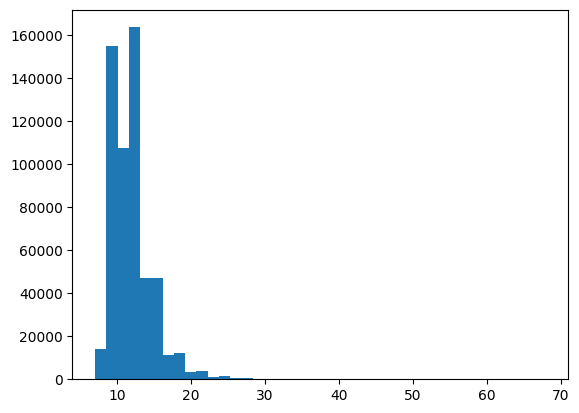

In [5]:
plt.hist(len_train_caption, bins = 40)

(array([3.394e+03, 4.203e+03, 4.661e+03, 4.065e+03, 5.032e+03, 1.241e+03,
        7.810e+02, 4.620e+02, 5.130e+02, 1.180e+02, 1.000e+02, 5.200e+01,
        3.700e+01, 6.200e+01, 2.200e+01, 2.200e+01, 1.000e+01, 8.000e+00,
        4.000e+00, 2.000e+00, 3.000e+00, 2.000e+00, 4.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([ 8.   ,  9.225, 10.45 , 11.675, 12.9  , 14.125, 15.35 , 16.575,
        17.8  , 19.025, 20.25 , 21.475, 22.7  , 23.925, 25.15 , 26.375,
        27.6  , 28.825, 30.05 , 31.275, 32.5  , 33.725, 34.95 , 36.175,
        37.4  , 38.625, 39.85 , 41.075, 42.3  , 43.525, 44.75 , 45.975,
        47.2  , 48.425, 49.65 , 50.875, 52.1  , 53.325, 54.55 , 55.775,
        57.   ]),
 <BarContainer object of 40 artists>)

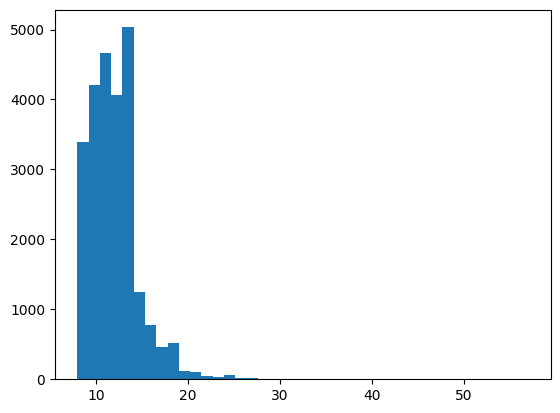

In [6]:
plt.hist(len_val_caption, bins = 40)

In [7]:
length_train_tokens = [(len(caption_token), caption) for caption, caption_token in raw_token_caption_train.items()]
length_val_tokens = [(len(caption_token), caption) for caption, caption_token in raw_token_caption_val.items()]

In [8]:
length_train_tokens.sort(reverse=True)
length_val_tokens.sort(reverse=True)

In [9]:
length_train_tokens[:10]

[(68,
  'A doorway  frames a telescopic view from a far off space with a multi-paned door, a chest of drawers and an oval rug on a wooden floor, up to a yellow room that has an oriental rug, chair, standing lamp, a widescreen T.V.,leather bench and ottoman.'),
 (67,
  'A green surface with  a fifties car model on a plate, topped with a hotdog roll and fries, a napkin dispenser, menus and condiments, has  two sets of  hands on either side, reaching for items, one of which is part of a black and  red/wearing woman. '),
 (65,
  'A rock fence, bisecting the upper part of the shot, separates, left, with foliage and a giraffe, only seen from the shoulders down, from right,  which has a wide, barren expanse, on which stands a zebra, and to the far right, a slatted fence.  '),
 (64,
  "The image shows an entertainment cubby in the background, and to the foreground, a low table with wine, glassware, plates of half-eaten food, and, to one side, a person's torso, legs and arms, the latter of whic

In [10]:
length_val_tokens[:10]

[(57,
  'A large square concrete wall, which shows people over the rim, has inside of it a pinkish cloud of dust and a fallen bull as well as two horses, the closest of which is trotting forward with a man in western gear , who is looking back at the bull.'),
 (54,
  'A man, his arm across the woman next to him, stands in a blandly colored kitchen area,  in front of a black-rimmed  window, next to a counter with a microwave, plates, with and without food, and wine bottles.  '),
 (53,
  'Three rectangular bowls with food; Big bowl has nine meat and sesame seed patties with brown sauce, next to it, a bowl of shredded cabbage and carrots with yogurt dollop atop, and behind that is a bowl of cut broccoli and tomatoes with seasoning.'),
 (47,
  'What appears to be a beach-side eatery has an outdoor area with a metal railing and high stools, the whole of which rests on a tilted walkway with a sign and  a bench with a logo on it. '),
 (46,
  'Side by side view of two oval plates, one with for

# 30 will be the context